# Unit06_Example_03 | 連續攪拌反應槽組之出口成分分析

本 Notebook 以 `scipy.linalg.solve()` 求解串並聯 CSTR 反應器網絡之穩態物料平衡線性方程組，分析各反應槽出口之反應物濃度。

## 目標
- 建立四槽 CSTR 反應器網絡的穩態物料平衡方程組 $\mathbf{Ax}=\mathbf{b}$
- 判斷係數矩陣 $\mathbf{A}$ 之秩與行列式，驗證唯一解存在
- 使用 `scipy.linalg.solve()` 求解出口濃度向量
- 驗證解的合理性（正值、質量守恆）
- 視覺化各槽出口濃度分布

資料來源：Constantinides and Mostoufi (1999), *Numerical Methods for Chemical Engineers with MATLAB Applications*

---
### 0. 環境設定

In [8]:
from pathlib import Path
import os

# ========================================
# 路徑設定 (兼容 Colab 與 Local)
# ========================================
UNIT_OUTPUT_DIR = 'Unit06_Example_03'

try:
    from google.colab import drive
    IN_COLAB = True
    print("✓ 偵測到 Colab 環境，準備掛載 Google Drive...")
    drive.mount('/content/drive', force_remount=True)
except ImportError:
    IN_COLAB = False
    print("✓ 偵測到 Local 環境")

try:
    shortcut_path = '/content/ChemE-3502'
    os.remove(shortcut_path)
except (FileNotFoundError, OSError):
    pass

if IN_COLAB:
    source_path = Path('/content/drive/My Drive/Colab Notebooks/ChemE-3502')
    os.symlink(source_path, shortcut_path)
    shortcut_path = Path(shortcut_path)
    if source_path.exists():
        NOTEBOOK_DIR = shortcut_path / 'Unit06'
        OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
        FIG_DIR      = OUTPUT_DIR / 'figs'
    else:
        print("⚠️ 找不到雲端 ChemE-3502 路徑，請確認資料夾名稱是否正確")
else:
    NOTEBOOK_DIR = Path.cwd()
    OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
    FIG_DIR      = OUTPUT_DIR / 'figs'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"\n✓ Notebook工作目錄: {NOTEBOOK_DIR}")
print(f"✓ 結果輸出目錄: {OUTPUT_DIR}")
print(f"✓ 圖檔輸出目錄: {FIG_DIR}")

✓ 偵測到 Local 環境

✓ Notebook工作目錄: d:\MyGit\ChemE-3502\Unit06
✓ 結果輸出目錄: d:\MyGit\ChemE-3502\Unit06\outputs\Unit06_Example_03
✓ 圖檔輸出目錄: d:\MyGit\ChemE-3502\Unit06\outputs\Unit06_Example_03\figs


---
### 1. 載入套件

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

from scipy import linalg

# 繪圖樣式設定
plt.rcParams.update({
    'figure.dpi': 100,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})

print(f"numpy  version: {np.__version__}")
import scipy
print(f"scipy  version: {scipy.__version__}")
import matplotlib
print(f"matplotlib version: {matplotlib.__version__}")

numpy  version: 1.23.5
scipy  version: 1.15.2
matplotlib version: 3.10.8


---
### 2. 問題描述

#### 題目：連續攪拌反應槽組之出口成分分析

考慮如下圖所示之四個串並聯連續攪拌反應槽（CSTR）網絡（Constantinides and Mostoufi, 1999）。

**系統假設**
1. 各槽進行一次不可逆液相反應 $A \rightarrow B$ ，且已達穩態
2. 各槽液體體積與密度之變化可忽略
3. 槽 $i$ 之反應速率 $r_i \ (\text{mol/h})$ 表示為：

$$
r_i = V_i \, k_i \, C_{Ai}
$$

**系統參數**

| 槽編號 | 體積 $V_i$ (L) | 反應常數 $k_i$ (h⁻¹) |
|:------:|:--------------:|:--------------------:|
| 1      | 1000           | 0.1                  |
| 2      | 1500           | 0.2                  |
| 3      | 100            | 0.4                  |
| 4      | 500            | 0.3                  |

**流量與進料條件**
- 進料流量： $F_{in} = 1000 \ \text{L/h}$ ，進料濃度： $C_{A0} = 1.0 \ \text{mol/L}$
- 槽2接收來自槽1（1000 L/h）及槽3（100 L/h），出口流量 1100 L/h
- 槽3接收來自槽2（1100 L/h）及槽4（100 L/h），出口流量 1200 L/h
- 槽4接收來自槽3（1100 L/h），出口流量 1100 L/h

#### 數學模型

依穩態質量守恆（輸入 = 輸出 + 反應消失），各槽之物料平衡方程式為：

$$
\text{槽1：} \ (1000 + V_1 k_1)\,C_{A1} = 1000 \, C_{A0}
$$

$$
\text{槽2：} \ - 1000\,C_{A1} + (1100 + V_2 k_2)\,C_{A2} - 100\,C_{A3} = 0
$$

$$
\text{槽3：} \ - 1100\,C_{A2} + (1200 + V_3 k_3)\,C_{A3} - 100\,C_{A4} = 0
$$

$$
\text{槽4：} \ - 1100\,C_{A3} + (1100 + V_4 k_4)\,C_{A4} = 0
$$

寫成矩陣形式 $\mathbf{A}\mathbf{x} = \mathbf{b}$ ：

$$
\begin{bmatrix}
1000 + V_1 k_1 & 0 & 0 & 0 \\
-1000 & 1100 + V_2 k_2 & -100 & 0 \\
0 & -1100 & 1200 + V_3 k_3 & -100 \\
0 & 0 & -1100 & 1100 + V_4 k_4
\end{bmatrix}
\begin{bmatrix} C_{A1} \\ C_{A2} \\ C_{A3} \\ C_{A4} \end{bmatrix}
=
\begin{bmatrix} 1000\,C_{A0} \\ 0 \\ 0 \\ 0 \end{bmatrix}
$$

**未知數**： $\mathbf{x} = [C_{A1}, C_{A2}, C_{A3}, C_{A4}]^T \ (\text{mol/L})$


---
### 3. 求解步驟

#### 步驟一：建立係數矩陣 $\mathbf{A}$ 與常數向量 $\mathbf{b}$

In [10]:
# ========================================
# 給定數據
# ========================================
V = np.array([1000, 1500, 100, 500])   # 各槽體積 (L)
k = np.array([0.1,  0.2,  0.4, 0.3])  # 各槽反應常數 (h⁻¹)
F_in  = 1000.0   # 進料流量 (L/h)
CA0   = 1.0      # 進料濃度 (mol/L)

# ========================================
# 建立係數矩陣 A (4×4)
# ========================================
A = np.array([
    [ F_in + V[0]*k[0],             0,                      0,                   0  ],
    [-F_in,              1100 + V[1]*k[1],               -100,                   0  ],
    [    0,                       -1100,       1200 + V[2]*k[2],               -100  ],
    [    0,                           0,                  -1100,   1100 + V[3]*k[3]  ]
])

# 常數向量 b
b = np.array([F_in * CA0, 0.0, 0.0, 0.0])

# ========================================
# 顯示矩陣 A 與向量 b
# ========================================
print("係數矩陣 A (4×4)：")
print(A)
print("\n常數向量 b：")
print(b)
print(f"\n各槽 V×k：{V*k}")
print(f"A[0,0] = {V[0]*k[0]} + {F_in} = {A[0,0]}")
print(f"A[1,1] = 1100 + {V[1]*k[1]} = {A[1,1]}")

係數矩陣 A (4×4)：
[[ 1100.     0.     0.     0.]
 [-1000.  1400.  -100.     0.]
 [    0. -1100.  1240.  -100.]
 [    0.     0. -1100.  1250.]]

常數向量 b：
[1000.    0.    0.    0.]

各槽 V×k：[100. 300.  40. 150.]
A[0,0] = 100.0 + 1000.0 = 1100.0
A[1,1] = 1100 + 300.0 = 1400.0


#### 步驟二：判斷解的唯一性

透過計算矩陣 $\mathbf{A}$ 的秩（rank）與行列式（determinant）來判斷方程組是否具有唯一解：

| 判斷指標 | 條件 | 結論 |
|:-------:|:----:|:----:|
| $\text{rank}(\mathbf{A}) = n$ | 秩等於未知數個數 | 有唯一解 |
| $\det(\mathbf{A}) \neq 0$ | 行列式不為零 | $\mathbf{A}$ 非奇異，有唯一解 |
| $\kappa(\mathbf{A}) \approx 1$ | 條件數接近1 | 數值穩定 |

In [11]:
n = len(b)

# 計算秩、行列式、條件數
rank_A = np.linalg.matrix_rank(A)
det_A  = np.linalg.det(A)
cond_A = np.linalg.cond(A)

print("=" * 40)
print("  矩陣 A 解的唯一性分析")
print("=" * 40)
print(f"  未知數個數 n   = {n}")
print(f"  rank(A)        = {rank_A}")
print(f"  det(A)         = {det_A:.4e}")
print(f"  κ(A) (條件數)  = {cond_A:.2f}")
print("-" * 40)

if rank_A == n and abs(det_A) > 1e-10:
    print("  ✓ A 為非奇異矩陣，方程組有唯一解")
else:
    print("  ✗ A 為奇異矩陣，方程組無唯一解")

  矩陣 A 解的唯一性分析
  未知數個數 n   = 4
  rank(A)        = 4
  det(A)         = 2.0663e+12
  κ(A) (條件數)  = 4.90
----------------------------------------
  ✓ A 為非奇異矩陣，方程組有唯一解


#### 步驟三：使用 `scipy.linalg.solve()` 求解

`scipy.linalg.solve(A, b)` 以 LU 分解（高斯消去法）直接求解 $\mathbf{Ax}=\mathbf{b}$ ，適用於非奇異方陣，得到各槽出口濃度 $[C_{A1}, C_{A2}, C_{A3}, C_{A4}]$ 。

In [12]:
# 求解線性方程組
x = linalg.solve(A, b)

CA1, CA2, CA3, CA4 = x

print("=" * 40)
print("  求解結果：各槽出口濃度")
print("=" * 40)
for i, ca in enumerate(x, start=1):
    print(f"  C_A{i} = {ca:.4f} mol/L")
print("-" * 40)
print(f"  進料濃度 C_A0 = {CA0:.4f} mol/L")
print(f"  最終出口 C_A4 / C_A0 = {CA4/CA0*100:.1f}%（總轉化率 {(1-CA4/CA0)*100:.1f}%）")

  求解結果：各槽出口濃度
  C_A1 = 0.9091 mol/L
  C_A2 = 0.6969 mol/L
  C_A3 = 0.6654 mol/L
  C_A4 = 0.5856 mol/L
----------------------------------------
  進料濃度 C_A0 = 1.0000 mol/L
  最終出口 C_A4 / C_A0 = 58.6%（總轉化率 41.4%）


#### 步驟四：解的驗證

驗證求得之解的合理性，包含：
1. **殘差驗證**：計算 $\|\mathbf{Ax} - \mathbf{b}\|_2$ ，應趨近於 0
2. **物理合理性**：各槽濃度應為正值且不超過進料濃度，且沿反應方向遞減
3. **質量守恆**：各槽物料進出平衡驗證

In [13]:
print("=" * 45)
print("  解的驗證")
print("=" * 45)

# 1. 殘差驗證
residual = np.linalg.norm(A @ x - b)
print(f"\n[1] 殘差 ||Ax - b||₂ = {residual:.4e}")
if residual < 1e-8:
    print("    ✓ 殘差極小，求解正確")

# 2. 物理合理性
print(f"\n[2] 物理合理性：")
all_positive = np.all(x > 0)
all_below_feed = np.all(x <= CA0)
print(f"    各槽濃度 C_Ai > 0 : {'✓' if all_positive else '✗'}")
print(f"    各槽濃度 C_Ai ≤ C_A0 : {'✓' if all_below_feed else '✗'}")

# 各槽濃度遞減驗證（近似，因網絡為非嚴格串聯）
print(f"    濃度變化：{CA0:.3f} → {CA1:.3f} → {CA2:.3f} → {CA3:.3f} → {CA4:.3f}")

# 3. 質量守恆驗證（各槽進出平衡）
print(f"\n[3] 各槽質量守恆驗證（進入濃度流 = 出口濃度流 + 反應消耗）：")
print("-" * 45)
# 槽1: 輸入1000*CA0, 輸出1000*CA1, 反應V1*k1*CA1
r1 = V[0]*k[0]*CA1
in1 = F_in * CA0
out1 = F_in * CA1
print(f"  槽1: 輸入={in1:.2f}, 輸出={out1:.2f}, 反應={r1:.2f}, 誤差={abs(in1-out1-r1):.2e}")

# 槽2: 輸入1000*CA1 + 100*CA3, 輸出1100*CA2, 反應V2*k2*CA2
r2 = V[1]*k[1]*CA2
in2 = 1000*CA1 + 100*CA3
out2 = 1100*CA2
print(f"  槽2: 輸入={in2:.2f}, 輸出={out2:.2f}, 反應={r2:.2f}, 誤差={abs(in2-out2-r2):.2e}")

# 槽3: 輸入1100*CA2 + 100*CA4, 輸出1200*CA3, 反應V3*k3*CA3
r3 = V[2]*k[2]*CA3
in3 = 1100*CA2 + 100*CA4
out3 = 1200*CA3
print(f"  槽3: 輸入={in3:.2f}, 輸出={out3:.2f}, 反應={r3:.2f}, 誤差={abs(in3-out3-r3):.2e}")

# 槽4: 輸入1100*CA3, 輸出1100*CA4, 反應V4*k4*CA4
r4 = V[3]*k[3]*CA4
in4 = 1100*CA3
out4 = 1100*CA4
print(f"  槽4: 輸入={in4:.2f}, 輸出={out4:.2f}, 反應={r4:.2f}, 誤差={abs(in4-out4-r4):.2e}")
print("-" * 45)

# 總反應消耗
total_reaction = r1 + r2 + r3 + r4
total_in  = F_in * CA0       # 進料
total_out = 1100 * CA4       # 最終出口 (槽4出口 1100 L/h)
# 注意：槽2/3 互相連結，計算網絡整體進出時用槽1進料 - 槽4出口
net_consumed = F_in*CA0 - 1100*CA4  # 整體網絡消耗 (但流量不完全守恆)
print(f"\n  總反應消耗  r_total = {total_reaction:.4f} mol/h")

  解的驗證

[1] 殘差 ||Ax - b||₂ = 1.1369e-13
    ✓ 殘差極小，求解正確

[2] 物理合理性：
    各槽濃度 C_Ai > 0 : ✓
    各槽濃度 C_Ai ≤ C_A0 : ✓
    濃度變化：1.000 → 0.909 → 0.697 → 0.665 → 0.586

[3] 各槽質量守恆驗證（進入濃度流 = 出口濃度流 + 反應消耗）：
---------------------------------------------
  槽1: 輸入=1000.00, 輸出=909.09, 反應=90.91, 誤差=8.53e-14
  槽2: 輸入=975.63, 輸出=766.57, 反應=209.06, 誤差=0.00e+00
  槽3: 輸入=825.13, 輸出=798.51, 反應=26.62, 誤差=3.55e-14
  槽4: 輸入=731.97, 輸出=644.13, 反應=87.84, 誤差=1.99e-13
---------------------------------------------

  總反應消耗  r_total = 414.4264 mol/h


---
### 4. 結果視覺化

繪製三張圖：
1. **各槽出口濃度棒狀圖**：含進料濃度參考線，顯示沿反應器網絡之濃度下降
2. **各槽反應消耗量長條圖**：顯示各槽反應貢獻量 $r_i = V_i k_i C_{Ai}$
3. **轉化率追蹤折線圖**：顯示各槽達到的累積轉化率

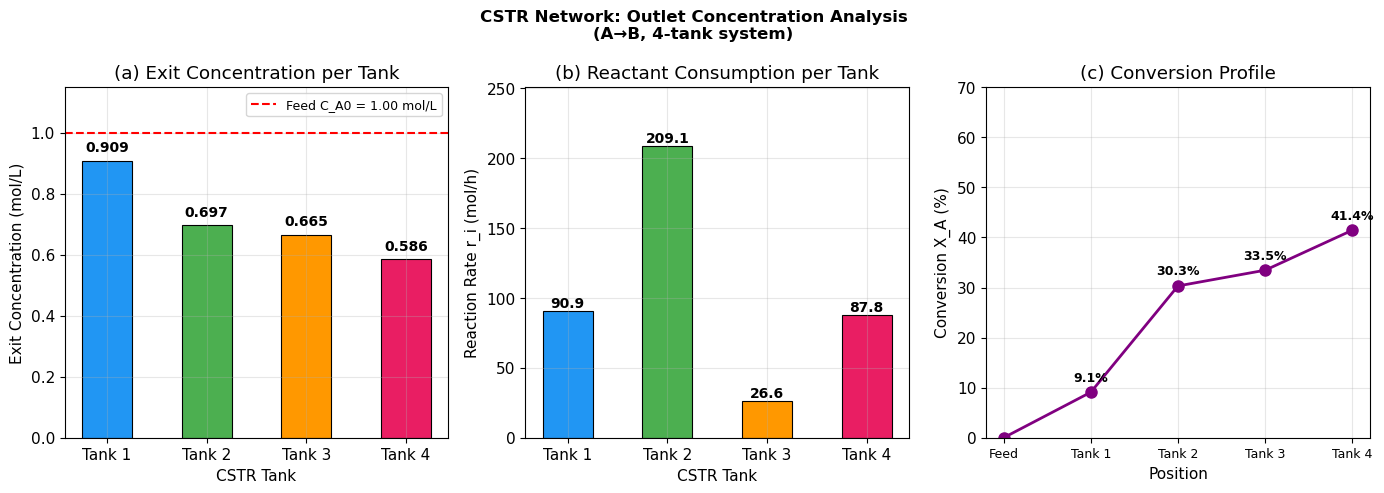


✓ 圖檔已儲存：d:\MyGit\ChemE-3502\Unit06\outputs\Unit06_Example_03\figs\cstr_network_solution.png


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

tank_labels = ['Tank 1', 'Tank 2', 'Tank 3', 'Tank 4']
colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']

# -----------------------------------------------
# 子圖1：各槽出口濃度棒狀圖
# -----------------------------------------------
ax1 = axes[0]
bars = ax1.bar(tank_labels, x, color=colors, width=0.5, edgecolor='black', linewidth=0.8)
ax1.axhline(y=CA0, color='red', linestyle='--', linewidth=1.5, label=f'Feed C_A0 = {CA0:.2f} mol/L')
ax1.set_xlabel('CSTR Tank')
ax1.set_ylabel('Exit Concentration (mol/L)')
ax1.set_title('(a) Exit Concentration per Tank')
ax1.set_ylim(0, 1.15)
ax1.legend(fontsize=9)
for bar, val in zip(bars, x):
    ax1.text(bar.get_x() + bar.get_width()/2, val + 0.02,
             f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# -----------------------------------------------
# 子圖2：各槽反應消耗量
# -----------------------------------------------
ax2 = axes[1]
r_vals = V * k * x
bars2 = ax2.bar(tank_labels, r_vals, color=colors, width=0.5, edgecolor='black', linewidth=0.8)
ax2.set_xlabel('CSTR Tank')
ax2.set_ylabel('Reaction Rate r_i (mol/h)')
ax2.set_title('(b) Reactant Consumption per Tank')
for bar, val in zip(bars2, r_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 0.3,
             f'{val:.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax2.set_ylim(0, max(r_vals)*1.2)

# -----------------------------------------------
# 子圖3：轉化率 (相對進料濃度)
# -----------------------------------------------
ax3 = axes[2]
conversion = (1 - x / CA0) * 100
all_points = np.concatenate([[0], conversion])
tank_pos = [0, 1, 2, 3, 4]
tank_tick_labels = ['Feed', 'Tank 1', 'Tank 2', 'Tank 3', 'Tank 4']

ax3.plot(tank_pos, all_points, 'o-', color='purple', linewidth=2, markersize=8)
for i, (pos, conv) in enumerate(zip(tank_pos[1:], conversion)):
    ax3.annotate(f'{conv:.1f}%', (pos, conv), textcoords="offset points",
                 xytext=(0, 8), ha='center', fontsize=9, fontweight='bold')
ax3.set_xticks(tank_pos)
ax3.set_xticklabels(tank_tick_labels, fontsize=9)
ax3.set_xlabel('Position')
ax3.set_ylabel('Conversion X_A (%)')
ax3.set_title('(c) Conversion Profile')
ax3.set_ylim(0, 70)

plt.suptitle('CSTR Network: Outlet Concentration Analysis\n(A→B, 4-tank system)', fontsize=12, fontweight='bold')
plt.tight_layout()

fig_path = FIG_DIR / 'cstr_network_solution.png'
plt.savefig(fig_path, dpi=120, bbox_inches='tight')
plt.show()
print(f"\n✓ 圖檔已儲存：{fig_path}")